<a href="https://colab.research.google.com/github/nalba97/TEXT-CSV-word-checker/blob/main/Copy_of_Week_2_Lab_Demo_Decision_Tree__Breast_Cancer_Data_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Week 2 Lab Demo: Decision Tree#

**Background**

The data was collected to identify whether a tumor biopsy was malignant or benign. A malignant tumor requires medical intervention.

Our task then is to develop the best possible diagnostic machine learning algorithm in order to assist the patient’s medical team in determining whether the tumor is malignant or not.

**Variables**
Ten real-valued features are computed for each cell nucleus:

a) radius8 (mean of distances from center to points on the perimeter)

b) texture (standard deviation of gray-scale values)

c) perimeter

d) area

e) smoothness (local variation in radius lengths)

f) compactness (perimeter^2 / area - 1.0)

g) concavity (severity of concave portions of the contour)

h) concave points (number of concave portions of the contour)

i) symmetry

j) fractal dimension ("coastline approximation" - 1)

k) **Diagnosis** (M = malignant, B = benign)

The mean, standard error and "worst" or largest (mean of the three largest values) of these features were computed for each image, resulting in 30 features. For instance, field 3 is Mean Radius, field 13 is Radius SE, field 23 is Worst Radius.


In [ ]:
## mount colab to google drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# define the path, please note you need to change the path to your own path that you use to save the dataset
path = "/content/drive/My Drive/Colab Notebooks/Datafiles/breast_cancer.csv"

In [ ]:
#read the data
import pandas as pd
cancer = pd.read_csv(path)

In [ ]:
# get the numer of rows and columns using .shape
cancer.shape

(569, 31)

In [ ]:
cancer.head(6)

,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,diagnosis
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,M
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,M
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,M
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,M
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,M
5,12.45,15.70,82.57,477.1,0.12780,0.17000,0.1578,0.08089,0.2087,0.07613,...,23.75,103.40,741.6,0.1791,0.5249,0.5355,0.1741,0.3985,0.12440,M


We use .iloc() to select predictors (the 1st to 30th columns) and save them to X, and save the target variable, which is in 31th column in y.

In [ ]:
# assign variables to X and y
X = cancer.iloc[: ,0:30].values
y = cancer.iloc[ :, 30].values

In [ ]:
X.shape

(569, 30)

Here we do label encoding for the target variable "diagnosis", since it is recorded in letters as "M" and "B". For most of data mining algorithm they cannot take letters directly, so we need to convert the letters into numbers.

In [ ]:
#labelencode the target variable
from sklearn.preprocessing import LabelEncoder
labelencoder_cancer = LabelEncoder()
y = labelencoder_cancer.fit_transform(cancer['diagnosis'].values)

In [ ]:
y

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1,
       1, 1, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 1, 1, 0, 0, 0, 0, 1, 0, 1, 1,
       0, 0, 0, 0, 1, 0, 1, 1, 0, 1, 0, 1, 1, 0, 0, 0, 1, 1, 0, 1, 1, 1,
       0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0,
       0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 1, 1, 0, 0, 0, 1, 1, 0, 1, 0, 1,
       1, 0, 1, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 0,
       0, 1, 0, 0, 1, 1, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 1, 1, 0, 1, 1,
       1, 1, 0, 1, 1, 1, 0, 1, 0, 1, 0, 0, 1, 0, 1, 1, 1, 1, 0, 0, 1, 1,
       0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 1, 1, 0, 1, 0, 0,
       0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 1, 0, 1, 1, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1,

In [ ]:
# In this step we check how many malignant and benign are in the target variable, malignant is coded as "1", benign is coded as "0"
cancer['diagnosis'].value_counts()

We usually split the data into training set and test set. We use the training set to create a model, and use the test set which is the set that is never used to create a model to evaluate the model, and see how the model is generalized to a new dataset.

In [ ]:
# use 25% of the original dataset as the test set, random_state =0 to make sure the spliting can be reproduced in the future
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.25, random_state = 0)

Now let's create a decision tree with parameters set to default values.Accuracy is a metrics that is used to evaluate the model performance, indiciating the percentage of instances among all instances are correctly classified.

In [ ]:
from sklearn.tree import DecisionTreeClassifier
tree = DecisionTreeClassifier(random_state=0)
tree.fit(X_train, y_train)

DecisionTreeClassifier(random_state=0)

In [ ]:
print("Accuracy on the training set:{:.3f}".format(tree.score(X_train, y_train)))

Accuracy on the training set:1.000


After creating the decision tree model on the training set, we evaluate this model in the test set to see how the model performs on a new dataset using .predict()

In [ ]:
y_pred = tree.predict(X_test)

The following syntax creates/visualize a confusion matrix that we can use to evaluate the model performance. We will talk about confusion matrix in depth in Week 5 and 6 course content.

In [ ]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)
print(cm)



[[76 14]
 [ 3 50]]


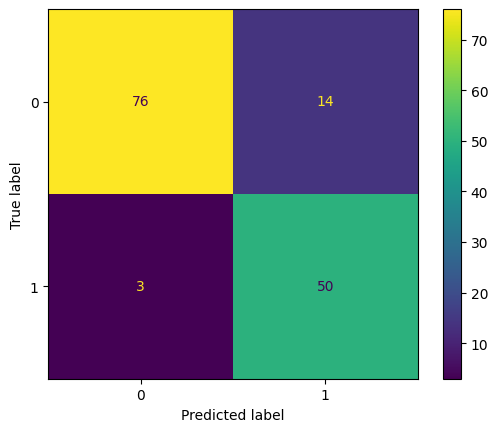

In [ ]:
# confusion matrix will be discussed in Week 5
#Plot_confusion_matrix() has been deprecated this year. We switch to ConfusionMatrixDisplay() instead.
from sklearn.metrics import ConfusionMatrixDisplay
ConfusionMatrixDisplay.from_estimator(tree,X_test,y_test)

To get the accuracy score of the model on test set, we use accuracy_score module form sklearn.metrics. And we can see accuracy on training set is 1, but accuracy on test set dropped to 0.881. This indicates a potential issue of overfitting.


In [ ]:
from sklearn.metrics import accuracy_score
print("Accuracy on the test set: {:.3f}".format(accuracy_score(y_pred, y_test)))

Accuracy on the test set: 0.881


The issue of overfitting

The accuracy on the training set is close to 100%—because the leaves are pure, the tree was grown deep enough that it could perfectly memorize all the labels on the training data.  Therefore it is prone to overfitting and not generalizing well to new data.

Now let’s apply pre-pruning to the tree, which will stop developing the tree before we perfectly fit to the training data. One option is to stop building the tree after a certain depth has been reached. Here we set max_depth=4. Limiting the depth of the tree decreases overfitting. This leads to a lower accuracy on the training set, but an improvement on the test set.



In [ ]:
# limit the depth of tree by setting max_depth = 4
tree_pruned = DecisionTreeClassifier(max_depth= 4, random_state=0)
tree_pruned.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=4, random_state=0)

In [ ]:
# evaluate the pruned tree on test set and we can see great improvement of model performance on test set
y_pruned_pred = tree_pruned.predict(X_test)

In [ ]:
print("Accuracy on the training set:{:.3f}".format(tree_pruned.score(X_train, y_train)))
print("Accuracy on the test set:{:.3f}". format(accuracy_score(y_pruned_pred, y_test)))

Accuracy on the training set:0.993
Accuracy on the test set:0.902


Next, let's visualizs the tree and get the importance of the variables that we use to create this decision tree. First we need to get the names of all the predictors since we need to use them in visualizing the tree.

In [ ]:
# we save the names of predictors into cancer_feature_names object
cancer_feature_names = cancer.iloc[ :,0:30].columns.tolist()
cancer_feature_names

['radius_mean',
 'texture_mean',
 'perimeter_mean',
 'area_mean',
 'smoothness_mean',
 'compactness_mean',
 'concavity_mean',
 'concave points_mean',
 'symmetry_mean',
 'fractal_dimension_mean',
 'radius_se',
 'texture_se',
 'perimeter_se',
 'area_se',
 'smoothness_se',
 'compactness_se',
 'concavity_se',
 'concave points_se',
 'symmetry_se',
 'fractal_dimension_se',
 'radius_worst',
 'texture_worst',
 'perimeter_worst',
 'area_worst',
 'smoothness_worst',
 'compactness_worst',
 'concavity_worst',
 'concave points_worst',
 'symmetry_worst',
 'fractal_dimension_worst']

In [ ]:
# we use export_graphviz to visualize the tree
from sklearn.tree import export_graphviz
dot_data = export_graphviz(tree, class_names=['benign','malignant'],
                           feature_names = cancer_feature_names,
                           filled = True,
                           out_file = None)

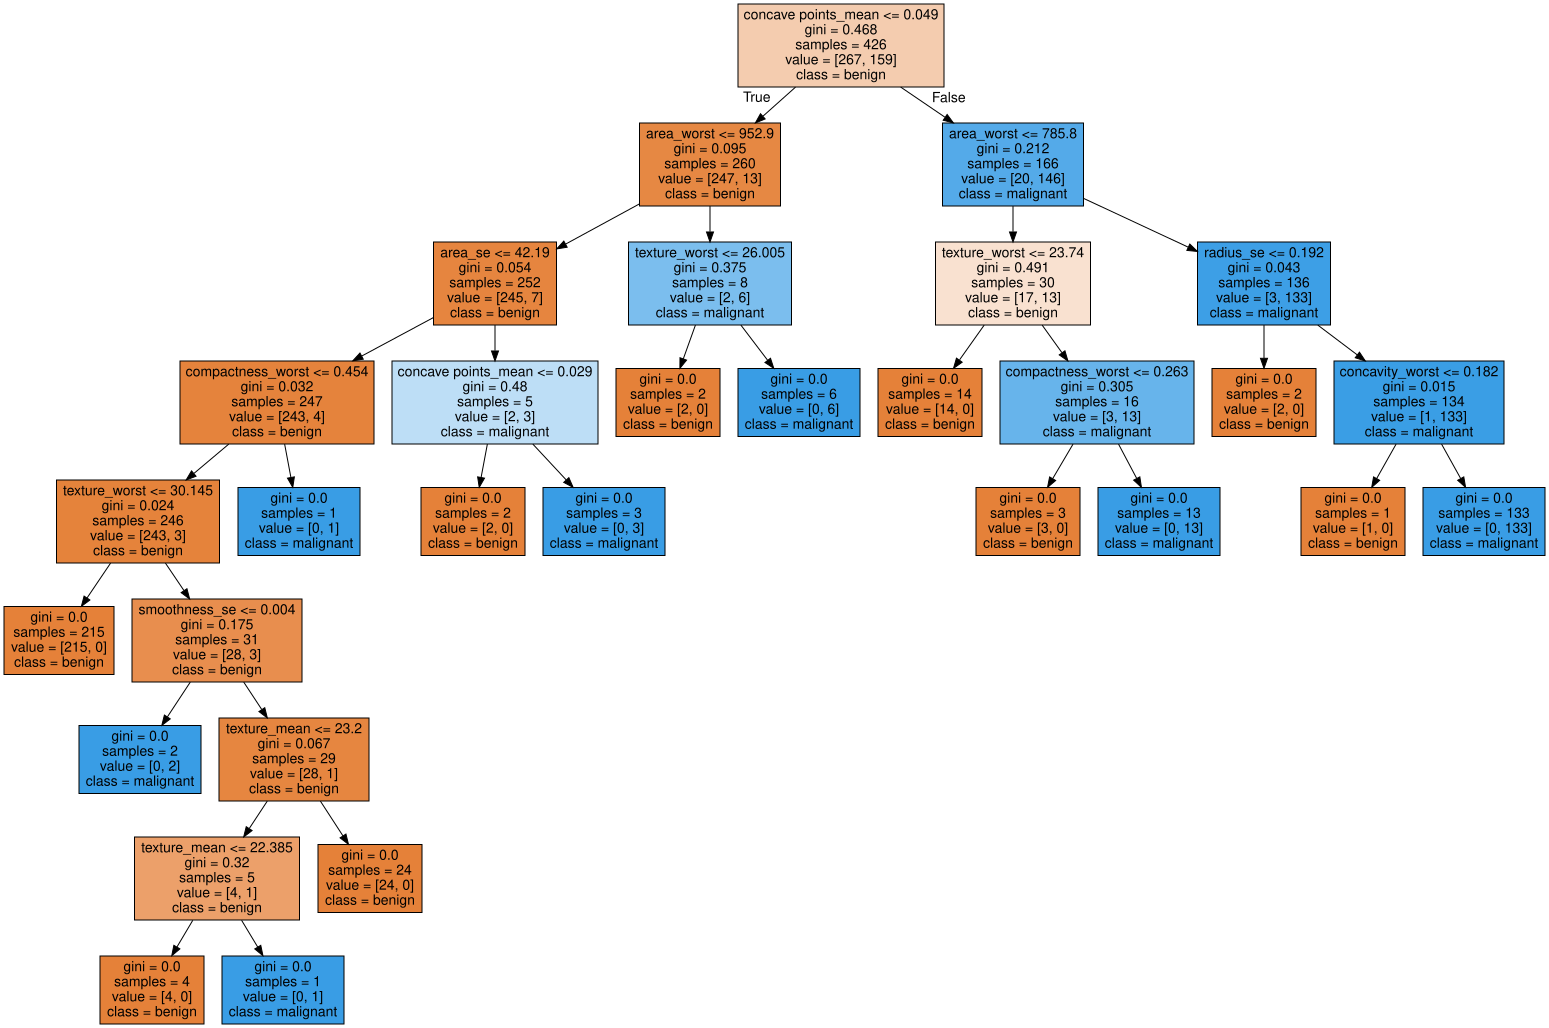

In [ ]:
import graphviz
graph = graphviz.Source(dot_data, format= "png")
graph

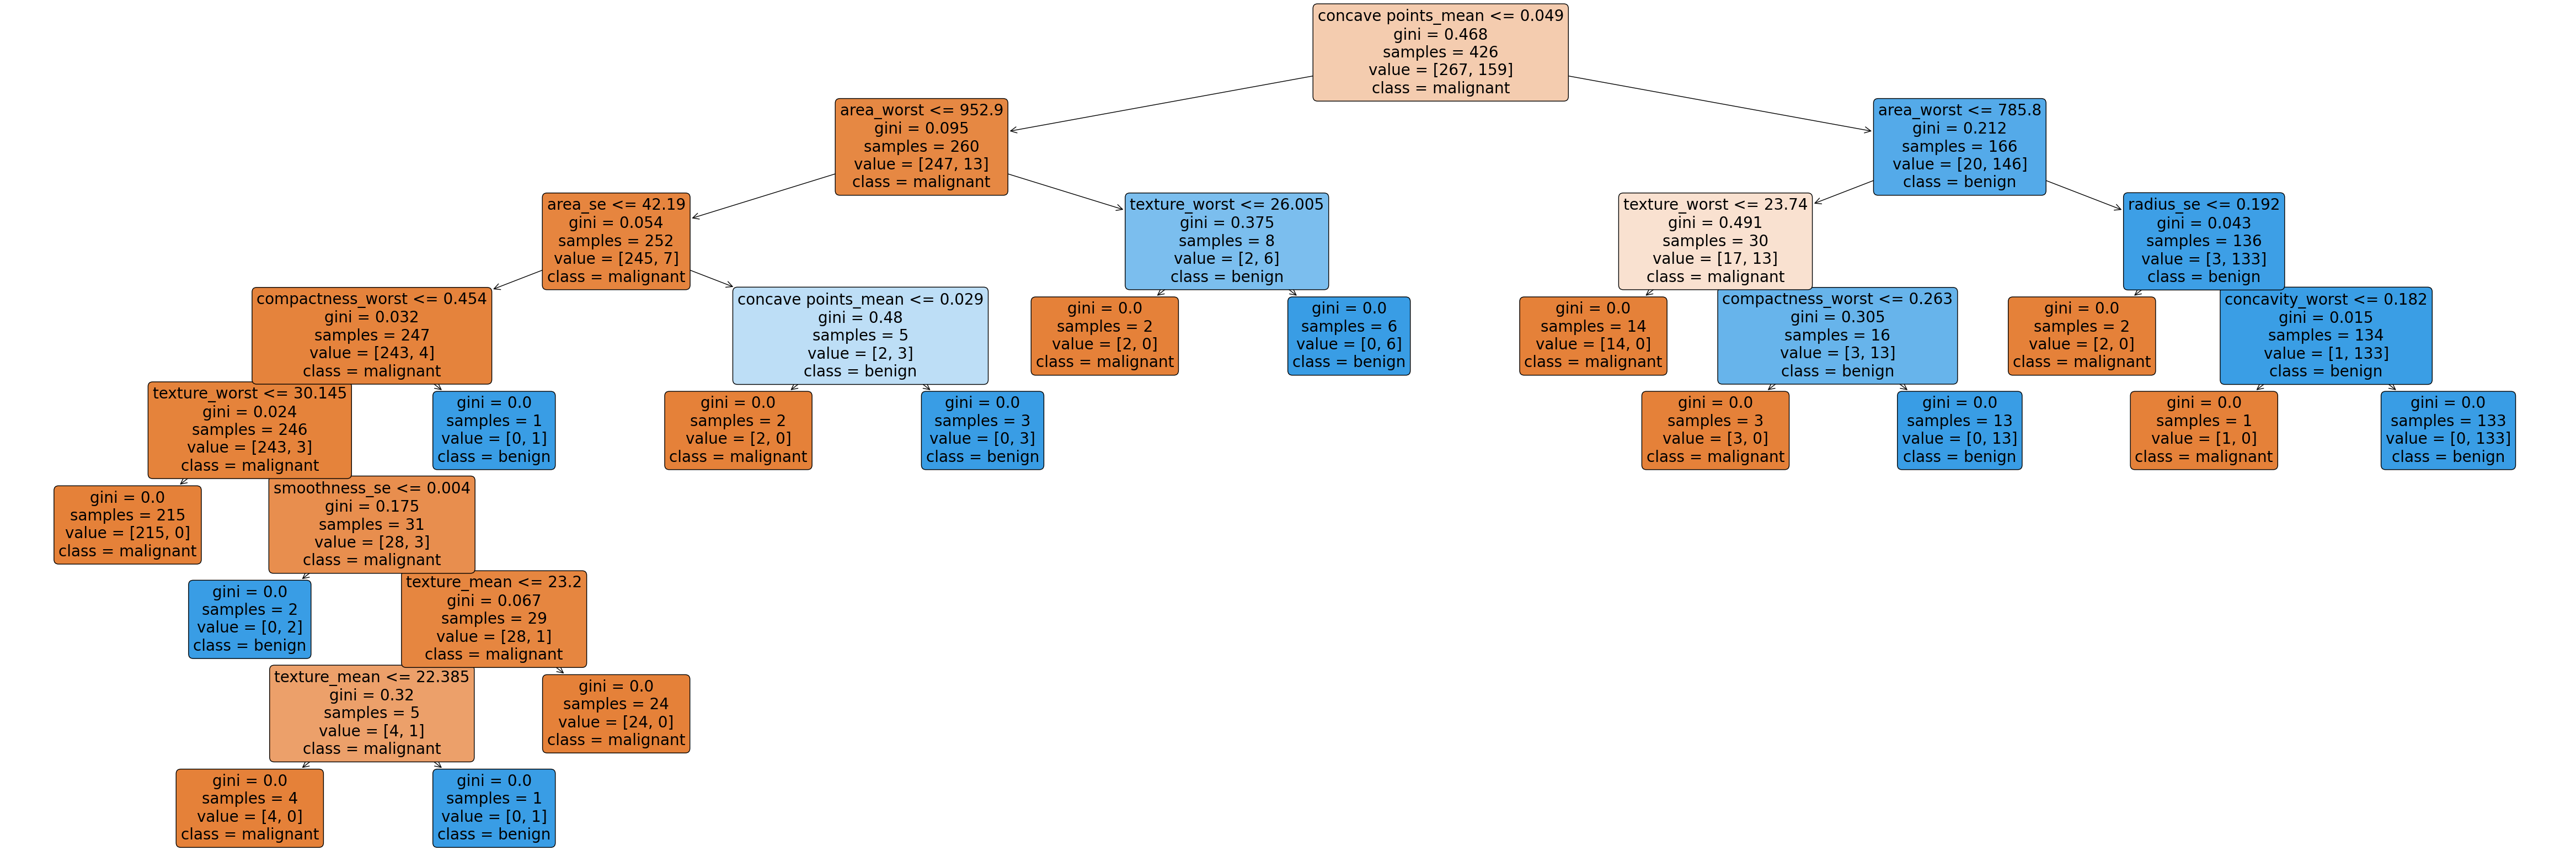

In [ ]:
# here is another easy to visualize the tree using plot_tree
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(60,20))  # set the size of the figure
display_tree = plot_tree(tree, # the name of decision tree that we want to visualize
              feature_names=cancer_feature_names,
              class_names=["malignant", "benign"],
              filled=True,
              rounded=True,
              fontsize=20)

The importance indicator of all predictors are save in .feature_importances_ attribute, we can create a dataframe to sort and show the feature importance. The variable with highest importance value is the most important one to predict if the tumor is malignant or benign.

In [ ]:
importance = pd.DataFrame(tree_pruned.feature_importances_, index = cancer_feature_names, columns=['Importance'])
importance.sort_values(by= "Importance", ascending= False )

,Importance
concave points_mean,0.721000
area_worst,0.117221
texture_worst,0.050978
compactness_worst,0.035260
perimeter_se,0.020077
area_se,0.017275
fractal_dimension_worst,0.015513
symmetry_se,0.012411
concavity_worst,0.010265
concave points_se,0.000000
